## Imports

In [1]:
import statsmodels as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.main import get_data

## EDA

[*********************100%***********************]  1 of 1 completed


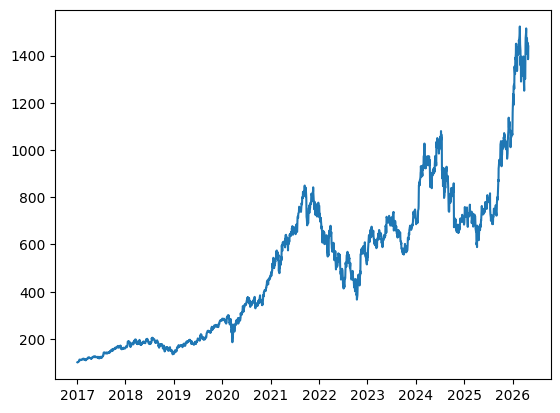

In [2]:
from src.indicators import calc_adx, calc_log_rt, calc_rvol
from src.regimes.config import load_config


cfg = load_config("configs/regimes.yaml")

data = get_data(cfg.stock.ticker, cfg.stock.start, cfg.stock.end)


data.columns = data.columns.droplevel(1)

adx = calc_adx(data["High"], data["Low"], data["Close"])["adx"]

close = data["Close"]
volume = data["Volume"]
plt.plot(close)
plt.show()

from src.indicators import calc_macd, rolling_zscore

macd = calc_macd(closing=close)
z_score = rolling_zscore(macd["histogram"], 20)

log_return = calc_log_rt(close)
realized_vol = calc_rvol(log_return)



df = pd.DataFrame({
    "close": close,
    "adx": adx,
    "log_close": np.log(close),
    "macd": macd["histogram"],
    "z_score": z_score,
    "rvol": realized_vol,
    "log_return": log_return
})
# df["close"] = close
# df["adx"] = adx
# df["log_close"] = np.log(close)

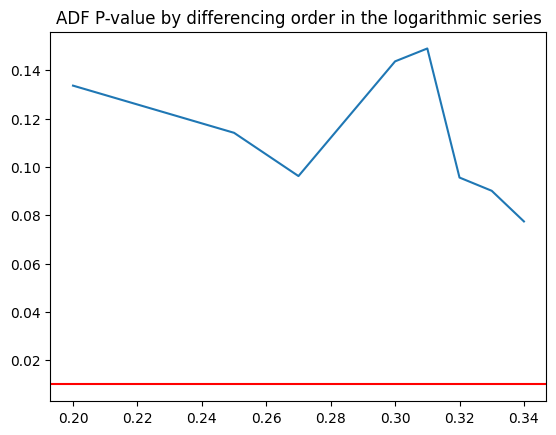

In [3]:
from src.features.frac_diff import differencing
from statsmodels.tsa.stattools import adfuller

possible_d=np.array([0.2, 0.25, 0.27, 0.3, 0.31, 0.32, 0.33, 0.34])

tau=1e-4
original_adf_stat_holder=[None]*len(possible_d)
log_adf_stat_holder=[None]*len(possible_d)

for i in range(len(possible_d)):
    log_adf_stat_holder[i]=adfuller(differencing(df["log_close"],possible_d[i],tau))[1]
    

plt.plot(possible_d,log_adf_stat_holder)
plt.axhline(y=0.01,color='r')
plt.title('ADF P-value by differencing order in the logarithmic series')
plt.show()

frac_diff autocorr(1): 0.957
frac_diff autocorr(20): 0.816


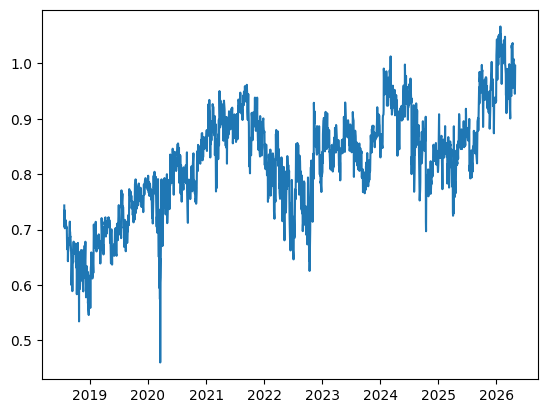

In [4]:
tau=1e-4

fd = differencing(df["log_close"],0.30,tau)
df["frac_diff"] = fd

print("frac_diff autocorr(1):",  df["frac_diff"].autocorr(1).round(3))
print("frac_diff autocorr(20):", df["frac_diff"].autocorr(20).round(3))

plt.plot(fd)
plt.show()

## Feature Engineering

In [5]:
from sklearn.preprocessing import StandardScaler


rvol_5 = calc_rvol(log_return, 5)
rvol_60 = calc_rvol(log_return, 60)

rvol_ratio = rvol_5 / rvol_60

df["rvol_ratio"] = rvol_ratio







df_clean = df.dropna()



features = pd.concat({
    "macd": df_clean["macd"],
    "frac_diff": df_clean["frac_diff"],  # direction
    # "log_return": df_clean["log_return"],
    "adx": np.log(df_clean["adx"]),
    "log_rvol": np.log(df_clean["rvol_ratio"]),                     # volatility (normalized)
}, axis=1, sort=True).dropna()


features_sliced = features["2022-01-01":"2025-12-31"]

scaler = StandardScaler()

X = scaler.fit_transform(features_sliced.values)
Y = scaler.transform(features.values)

features

,macd,frac_diff,adx,log_rvol
Date,,,,
2018-07-23,2.648501,0.743569,3.122744,-0.818356
2018-07-24,2.202275,0.704685,3.121044,-0.587480
2018-07-25,2.106975,0.734957,3.119462,-1.025899
2018-07-26,1.781767,0.717562,3.111285,-1.034207
2018-07-27,1.264373,0.702288,3.084838,-1.130419
...,...,...,...,...
2026-04-24,1.171997,0.998842,2.636870,-1.638117
2026-04-27,-0.683890,0.976908,2.625153,-1.653648
2026-04-28,-5.060272,0.945277,2.668475,-1.468409


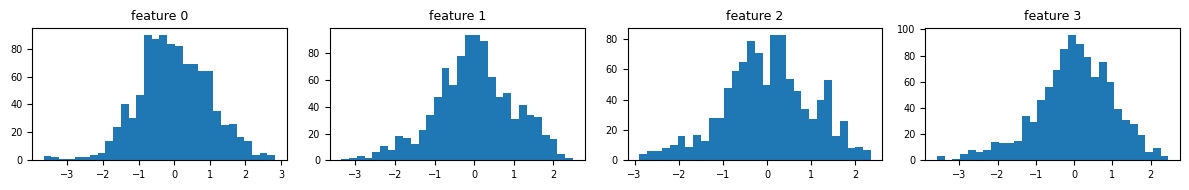

In [6]:
# compact grid of histograms for every feature
n_features = X.shape[1]
n_cols     = 4
n_rows     = -(-n_features // n_cols)  # ceil div

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols*3, n_rows*2),
                         tight_layout=True)
axes = axes.ravel()

for i in range(n_features):
    axes[i].hist(X[:, i], bins=30)
    axes[i].set_title(f"feature {i}", fontsize=9)
    axes[i].tick_params(labelsize=7)

# hide unused axes
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.show()

## Training

In [7]:
close.shape

(2344,)

In [8]:
from pathlib import Path

from hmmlearn.hmm import GaussianHMM

from src.regimes.config import load_config
from src.regimes.run import run_regime_search

fwd = close.loc[features.index].pct_change().shift(-1).reindex(features.index)
cfg = load_config("configs/regimes.yaml")

out, dir = run_regime_search(cfg, X, features, Y, scaler, forward_returns=fwd)



AttributeError: 'NoneType' object has no attribute 'info'

In [ ]:
# import matplotlib.pyplot as plt
# from collections import defaultdict

# bic_by_n = defaultdict(list)

# for model in result["models"]:
#     bic_by_n[model["n_components"]].append(model["bic"])

# cmap = plt.get_cmap("tab10")
# for i, (n, bics) in enumerate(sorted(bic_by_n.items())):
#     plt.plot(bics, color=cmap(i), label=f"n_components={n}")

# plt.xlabel("model index (within n_components)")
# plt.ylabel("BIC")
# plt.legend()
# plt.show()

## Results

In [ ]:
from src.regimes.archive import RegimeRunArchive


archive = RegimeRunArchive(cfg.output.dir)

archive.list_runs(cfg.stock.ticker)

,run_id,sub_run,ticker,n_components,cov_type,bic,aic,score,switch_rate,min_dwell_days,converged,seed,start,end
0,20260602_234713,NaN,AA,3,diag,9795.193409,9638.049384,-4787.024692,0.037924,23.416210,True,660301,2017-01-01,2026-05-01
1,20260603_222404,seed_217495_3,AA,3,full,21553.969988,21275.088296,-10587.544148,0.037378,16.400388,True,217495,2017-01-01,2026-05-01
2,20260603_221732,seed_264908_3,AA,3,full,21597.022814,21318.141123,-10609.070561,0.048643,14.187991,True,264908,2017-01-01,2026-05-01
3,20260603_222404,seed_371834_3,AA,3,full,21620.022295,21341.140603,-10620.570302,0.041475,13.690385,True,371834,2017-01-01,2026-05-01
4,20260603_221732,seed_982609_3,AA,3,full,21721.149970,21442.268278,-10671.134139,0.033794,17.066840,True,982609,2017-01-01,2026-05-01
5,20260603_222404,seed_79243_3,AA,3,full,21721.640365,21442.758673,-10671.379337,0.033794,17.070295,True,79243,2017-01-01,2026-05-01
6,20260603_221732,seed_244324_3,AA,3,full,21752.669494,21473.787802,-10686.893901,0.046083,15.340589,True,244324,2017-01-01,2026-05-01
7,20260603_221732,seed_958337_3,AA,3,full,21898.796052,21619.914360,-10759.957180,0.053763,11.897170,True,958337,2017-01-01,2026-05-01
8,20260603_221732,seed_909555_3,AA,3,full,21979.739613,21700.857921,-10800.428960,0.031746,20.239177,True,909555,2017-01-01,2026-05-01
9,20260603_222404,seed_284134_3,AA,3,full,22072.928452,21794.046760,-10847.023380,0.030722,22.298184,True,284134,2017-01-01,2026-05-01


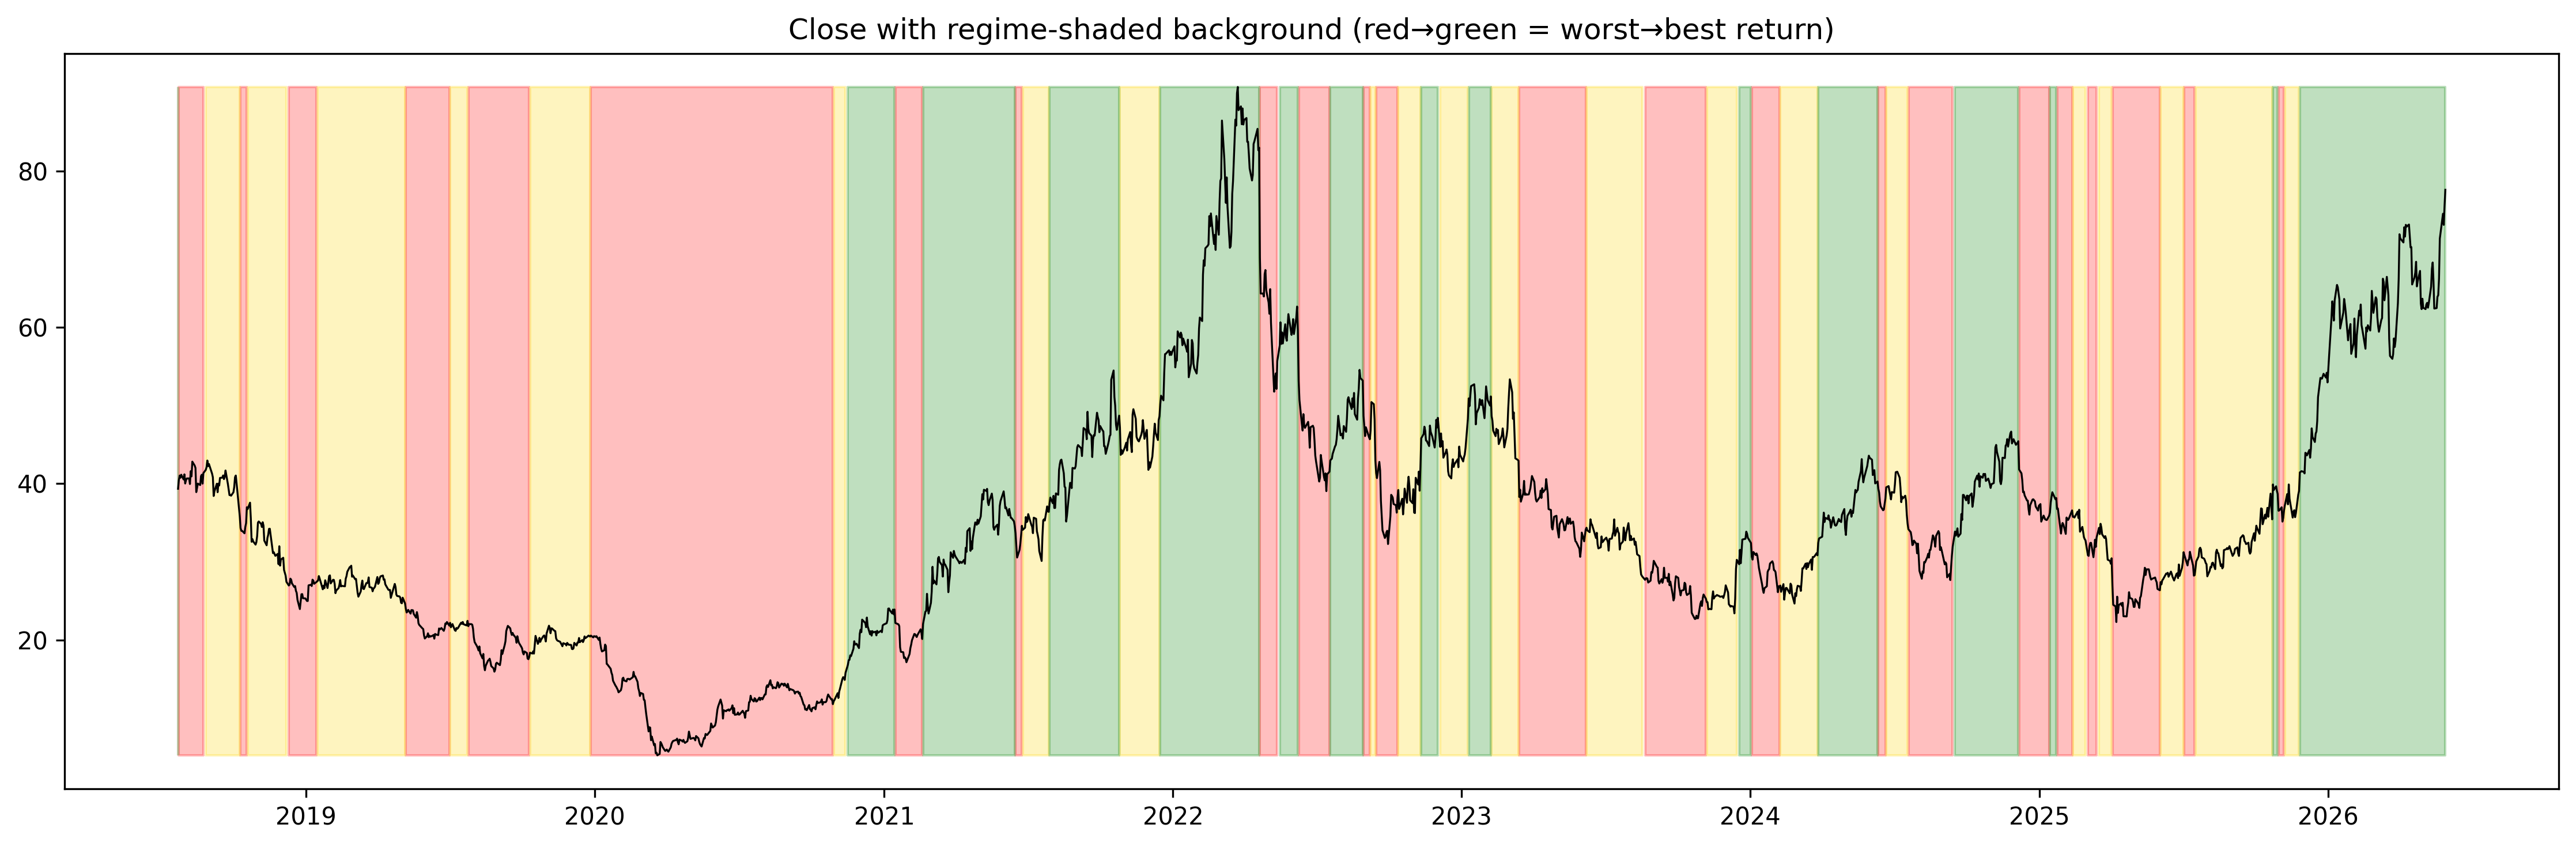

In [ ]:
bundle = archive.load_sub_run("AA", "20260602_234713", "seed_660301_3")

model  = bundle["model"]
scaler = bundle["scaler"]
feats  = bundle["feature_names"]
metrics = bundle["metrics"]        # the full metrics.json: transmat, regime_stats, etc.

preds = model.predict(Y)

import matplotlib.colors as mcolors

price = df["close"].loc[features.index].values.flatten()

df_val = pd.DataFrame({
    'regime': preds.squeeze(),
    'next_return': close.loc[features.index].pct_change().shift(-1).values.squeeze()
}, index=features.index)

ramp = mcolors.LinearSegmentedColormap.from_list("regime", ["red", "gold", "green"])
palette = [ramp(i / (model.n_components - 1))
           for i in range(model.n_components)]

means = [df_val[df_val.regime == r].next_return.mean()
         for r in range(model.n_components)]



order = np.argsort(means)
remap = {old: new for new, old in enumerate(order)}
preds_sorted = np.array([remap[r] for r in preds])

fig, ax = plt.subplots(figsize=(15, 5), dpi=300)

ax.plot(features.index, price, color="black", lw=0.8)

for r in range(model.n_components):
    mask = preds_sorted == r
    ax.fill_between(
        features.index,
        price.min(),
        price.max(),
        where=mask,
        color=palette[r],
        alpha=0.25,
        step="mid"
    )

ax.set_title("Close with regime-shaded background (red→green = worst→best return)")

plt.tight_layout()
plt.show()

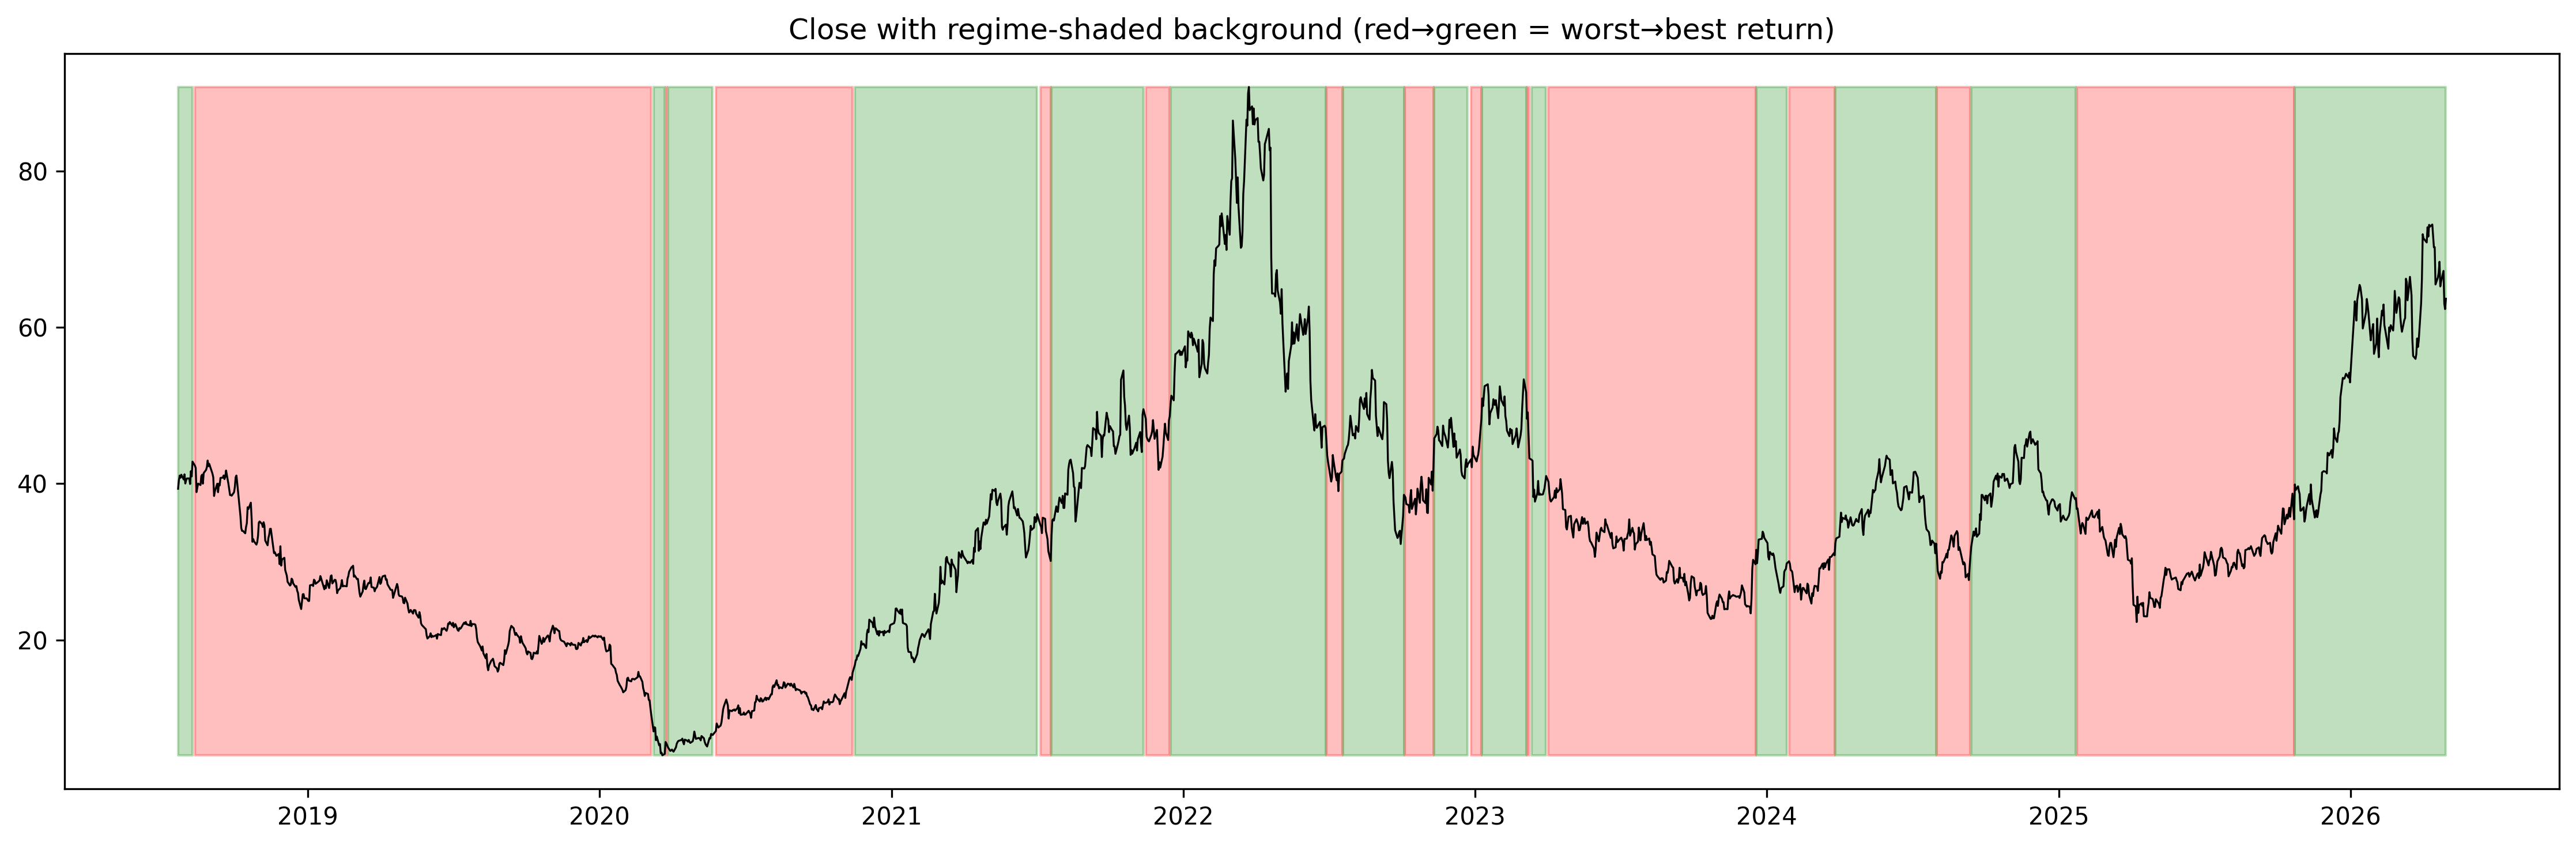